# Detecting Tuberculosis in X-Rays

## 📖 Background
Tuberculosis (TB) is one of the most common and deadly respiratory diseases in the world, causing about [1.25 million people in 2023](https://www.who.int/teams/global-programme-on-tuberculosis-and-lung-health/tb-reports/global-tuberculosis-report-2024/tb-disease-burden/1-2-tb-mortality).
Doctors often use chest X-rays to help detect TB. However, looking at many X-rays by hand can be slow and difficult.

In this challenge, you will build a simple machine learning model that can help classify chest X-ray images into two groups:

- Healthy lungs
- Lungs affected by TB

This is not about building a “perfect” model. The focus should be on how you describe your process, decisions, and learnings.



## 🩻 The Data

<img src="x-rays_sample.png" align="center"/>
&nbsp

You are given a small dataset from the Sakha-TB dataset:

- Training data: 150 healthy + 150 TB images (300 total)
- Test data: 50 healthy + 50 TB images (100 total)

These images are in the **data.zip** file at the root of the notebook. They will then be in the `data/chestxray` folder, which is further divided into `test` and `train`, both containing `healthy` and `tb` folders with the images inside.

## 💪 Challenge


You will train a model to classify chest X-rays. Your report should cover these questions:

1. **Preprocessing**  
   What steps did you take to make the images easier for a model to understand?  
   Some ideas to think about:  
   - Did you resize the images to the same size?  
   - Did you convert them to grayscale or normalize the pixel values?  
   - Did you try any simple image transformations (e.g., small rotations)?  

2. **Modeling**  
   Try at least **two models** and compare them.  
   - One can be a simple model you build yourself (like a small CNN).  
   - Another can be a pre-trained model (like ResNet or MobileNet).  
   Explain what you tried and what differences you observed.  

3. **Evaluation**  
   Evaluate your models on the test set. Report the following metrics in plain words:  
   - **Sensitivity (Recall for TB):** How many TB cases your model correctly finds.  
   - **Specificity:** How many healthy cases your model correctly identifies.  
   - **Positive Predictive Value (PPV):** When your model says “TB”, how often it’s right.  
   - **Negative Predictive Value (NPV):** When your model says “Healthy”, how often it’s right.  

   👉 *Tip: You don’t need to get the “best” numbers. Focus on explaining what the metrics mean and what you learned.*  

4. **[Optional] ROC Curve**  
   If you want, you can also draw a Receiver Operating Characteristic (ROC) curve to visualize how your model performance changes with different thresholds.


## ✅ Checklist before publishing
- Rename your workspace to make it descriptive of your work. N.B. you should leave the notebook name as notebook.ipynb.
- **Remove redundant cells** like the introduction to data science notebooks, so the workbook is focused on your story.
- Check that all the cells run without error.

## ⌛️ Time is ticking. Good luck!

In [1]:
import os
import zipfile

# Unzip the data folder
if not os.path.exists('data/chestxrays'):
    with zipfile.ZipFile('data.zip', 'r') as zip_ref:
        zip_ref.extractall()

In [2]:
train_dir = "data/chestxrays/train"
test_dir  = "data/chestxrays/test"

def count_images(folder):
    return len(os.listdir(folder))

print("Train Healthy:", count_images(os.path.join(train_dir, "healthy")))
print("Train TB:", count_images(os.path.join(train_dir, "tb")))

print("Test Healthy:", count_images(os.path.join(test_dir, "healthy")))
print("Test TB:", count_images(os.path.join(test_dir, "tb")))


Train Healthy: 152
Train TB: 151
Test Healthy: 50
Test TB: 50


**the training dataset is almost balanced, with a small diference between healthy and TB images.**

2026-02-02 13:04:02.416345: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770037442.430582     453 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770037442.434930     453 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770037442.447300     453 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770037442.447313     453 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770037442.447316     453 computation_placer.cc:177] computation placer alr

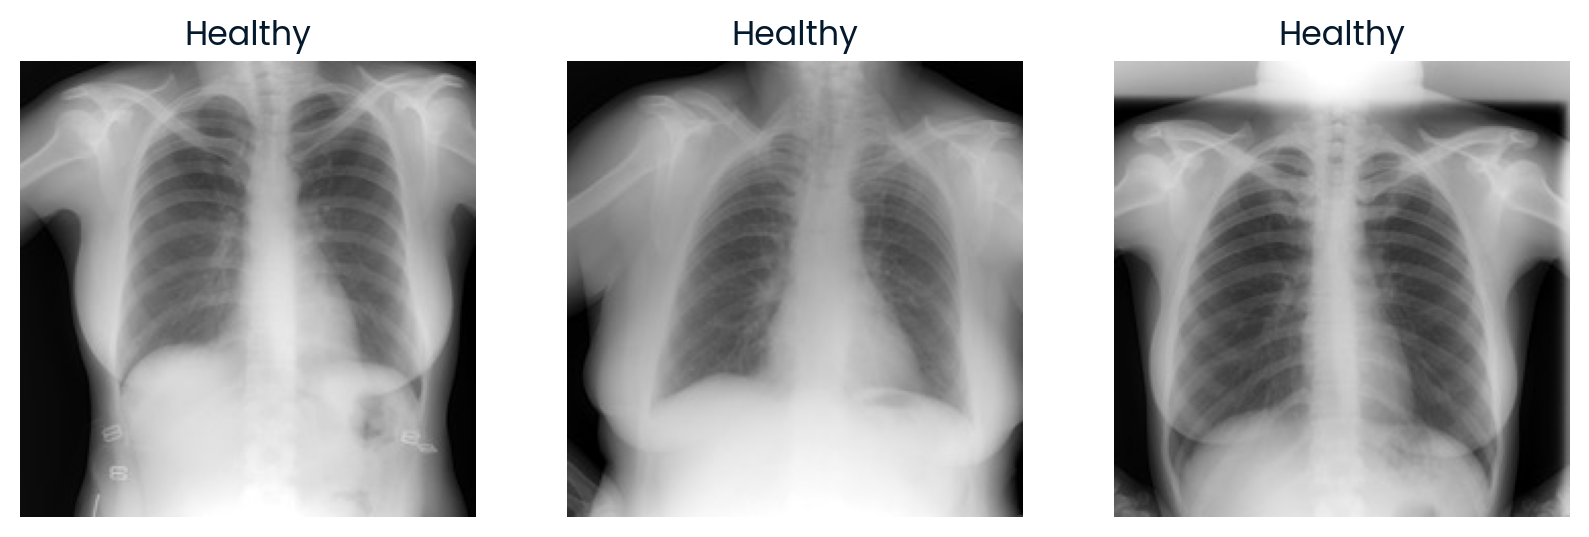

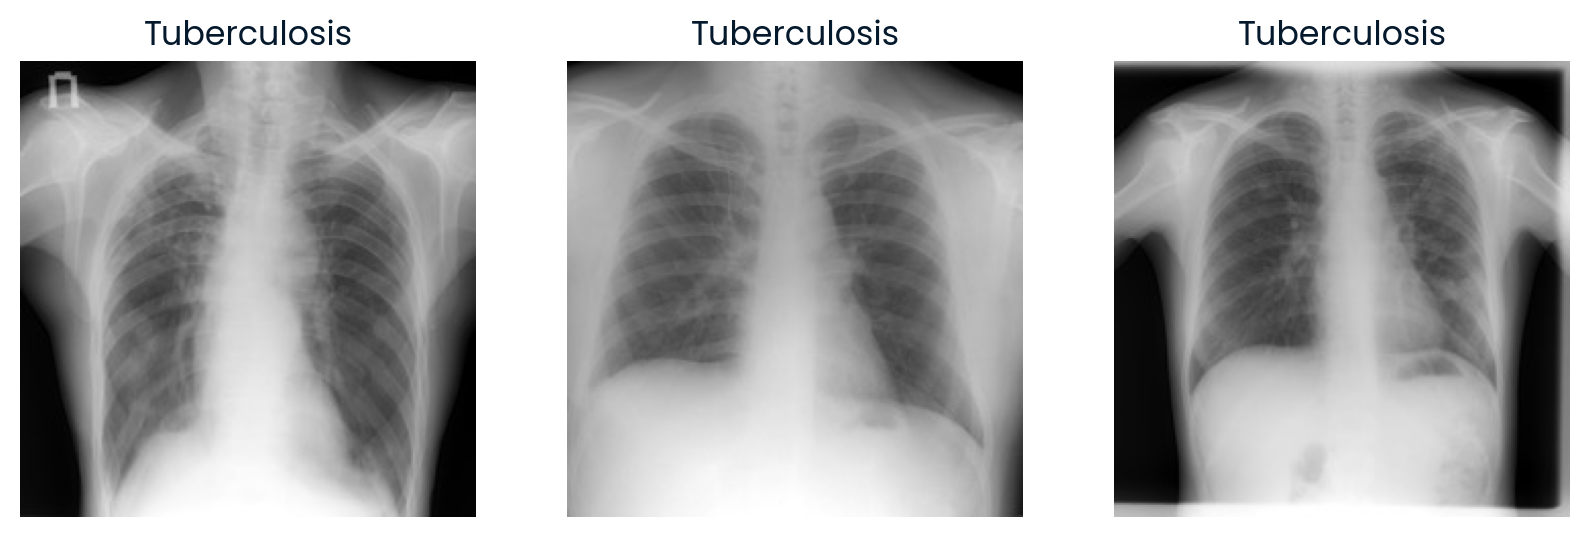

In [3]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import random

import matplotlib.pyplot as plt  

def show_random_images(folder, label, n=3):
    plt.figure(figsize=(10, 4))
    images = random.sample(os.listdir(folder), n)
    
    for i, img_name in enumerate(images):
        img_path = os.path.join(folder, img_name)
        img = load_img(img_path)
        img_array = img_to_array(img)
        
        plt.subplot(1, n, i+1)
        plt.imshow(img_array.astype("uint8"))
        plt.axis("off")
        plt.title(label)
    
    plt.show()

show_random_images(os.path.join(train_dir, "healthy"), "Healthy")
show_random_images(os.path.join(train_dir, "tb"), "Tuberculosis")


chest X-ray images are in size and appearance. Visual inspection shows subtle differences between cases.

In [4]:
IMG_SIZE = (224, 224)   
BATCH_SIZE = 16 

_all images must be resized to 224*224 pixels to ensure a consistent input size_

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1./255,        # normalisation des pixels
    rotation_range=10,     # petites rotations
    zoom_range=0.1,        # léger zoom
    horizontal_flip=True  # symétrie horizontale
)
train_dir = "data/chestxrays/train"

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 302 images belonging to 2 classes.


_Augmentation was applied to the training set to improve generalization_

In [6]:

images, labels = next(train_generator)

print("Images batch shape:", images.shape) 
print("Labels batch:", labels[:10])        

Images batch shape: (16, 224, 224, 3)
Labels batch: [0. 0. 0. 1. 1. 0. 0. 1. 1. 0.]


In [7]:
from tensorflow.keras import models, layers

# Modèle CNN simple
model = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # 1 neurone car classification binaire
])

model.summary()

2026-02-02 13:04:20.156925: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,768,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,792,609 (10.65 MB)

 Trainable params: 2,792,609 (10.65 MB)

 Non-trainable params: 0 (0.00 B)


simple CNN was built with 3 convolutinal layers followed by max-pooling layers,then a dense layer and sigmoid output for classifcation

In [8]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',  
    metrics=['accuracy']
)


In [10]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)


history = model.fit(
    train_generator,
    epochs=30,               # petit nombre pour test rapide
    validation_data=test_generator
)


Found 100 images belonging to 2 classes.
Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 701ms/step - accuracy: 0.6797 - loss: 0.6142 - val_accuracy: 0.7500 - val_loss: 0.5754
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 678ms/step - accuracy: 0.6911 - loss: 0.5748 - val_accuracy: 0.8000 - val_loss: 0.5076
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 662ms/step - accuracy: 0.7737 - loss: 0.4863 - val_accuracy: 0.7800 - val_loss: 0.4406
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 668ms/step - accuracy: 0.7378 - loss: 0.5072 - val_accuracy: 0.7600 - val_loss: 0.5473
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 668ms/step - accuracy: 0.6858 - loss: 0.5416 - val_accuracy: 0.7700 - val_loss: 0.5498
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 662ms/step - accuracy: 0.7094 - loss: 0.5300 - val_accuracy: 0.7900 - val_loss: 0.4449
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 668ms/step - accuracy: 0.7132 - loss: 0.5259 - val_accuracy: 0.8100 - val_loss: 0.4326
Epoch 8/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 668ms/step - a

_CNN achieve a training accurancy around ~74 % and validation accurency around 86 %._

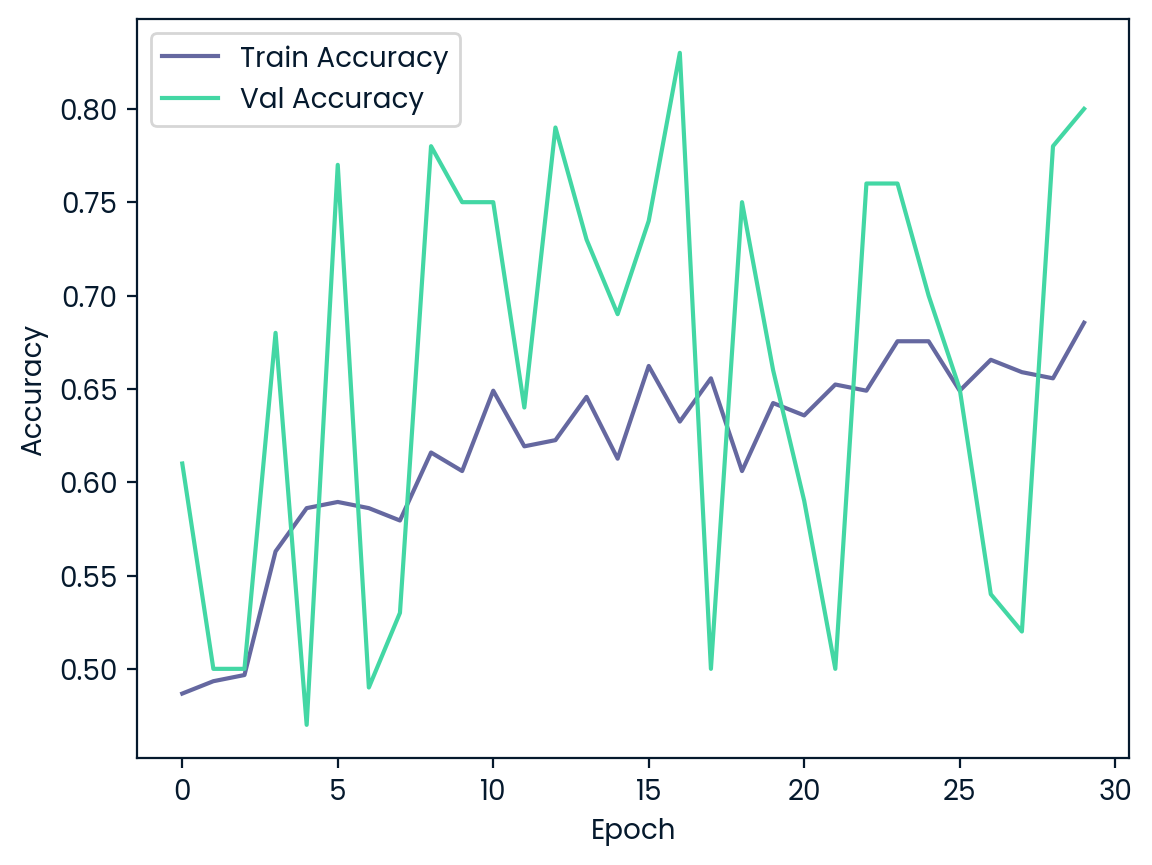

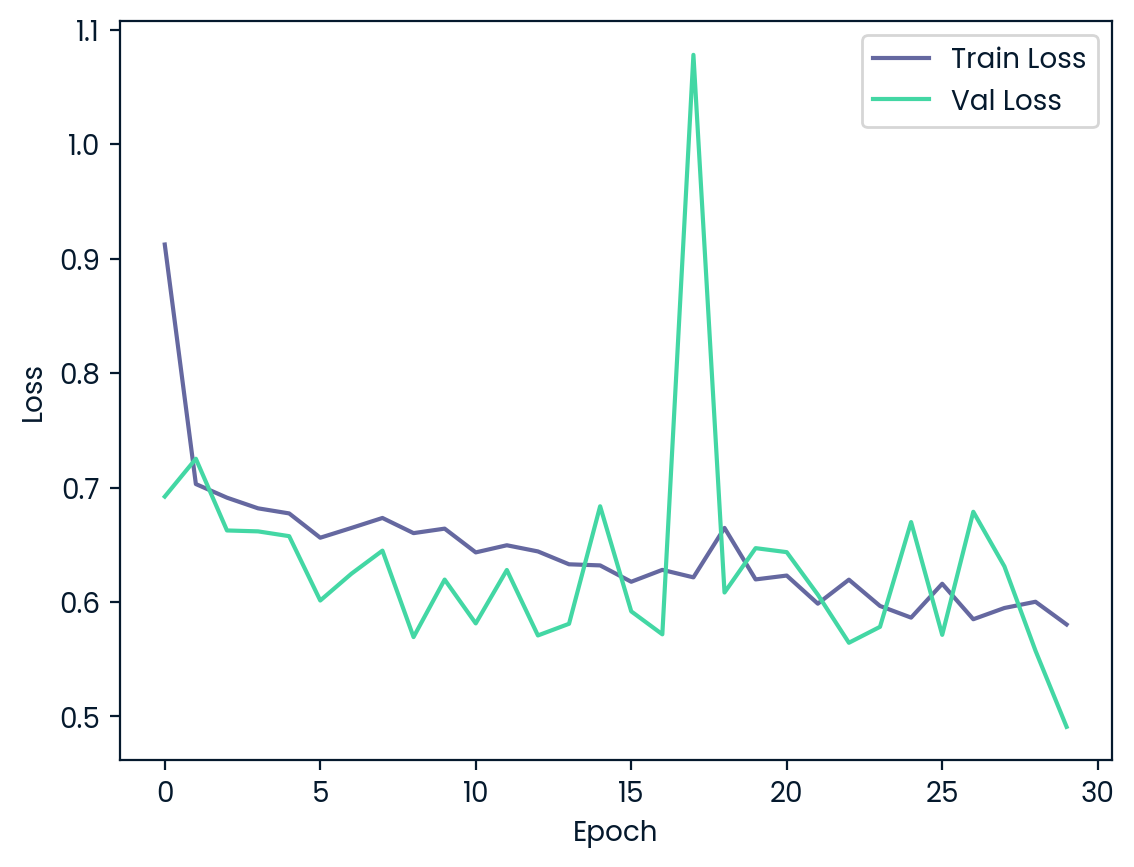

In [32]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [11]:
from sklearn.metrics import confusion_matrix

# Prédictions sur tout le test set
test_generator.reset()
pred_probs = model.predict(test_generator)
pred_labels = (pred_probs > 0.5).astype(int)

# Vrais labels
true_labels = test_generator.classes

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(true_labels, pred_labels).ravel()

# Calcul des métriques
sensitivity = tp / (tp + fn)          # Recall pour TB
specificity = tn / (tn + fp)
ppv = tp / (tp + fp)                  # Precision pour TB
npv = tn / (tn + fn)

print(f"Sensitivity (Recall for TB): {sensitivity:.2f}")
print(f"Specificity (True Healthy): {specificity:.2f}")
print(f"PPV (Precision for TB): {ppv:.2f}")
print(f"NPV (Precision for Healthy): {npv:.2f}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step
Sensitivity (Recall for TB): 0.64
Specificity (True Healthy): 0.96
PPV (Precision for TB): 0.94
NPV (Precision for Healthy): 0.73


the model has high specifity and precision for TB, indicating it rarely misclassifies healthy patients as sick.